In [12]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
from torch import optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Loading dataset from the CSV file

In [13]:
df = pd.read_csv('HomeDataset_after_preprocess_04_06.csv')
df.head()

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,...,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment,address_encoded,room_to_area
0,4.0,1,1.183908e+08,27.0,8,22.0,10.0,0.0,1.0,0.0,...,50.0,15.0,15.0,1.0,1.0,1.0,1.0,6,1.212189e+08,0.022989
1,5.0,2,1.400000e+08,0.0,8,22.0,10.0,1.0,0.0,0.0,...,50.0,15.0,10.0,1.0,1.0,1.0,1.0,20,1.060243e+08,0.023810
2,5.0,1,1.363636e+08,0.0,8,22.0,10.0,0.0,1.0,0.0,...,50.0,15.0,10.0,1.0,1.0,1.0,1.0,21,1.168818e+08,0.030303
3,4.0,1,5.250000e+07,18.0,8,22.0,3.0,0.0,1.0,0.0,...,50.0,5.0,10.0,1.0,0.0,0.0,1.0,3,9.027674e+07,0.037500
4,4.0,4,1.400000e+08,3.0,8,22.0,10.0,1.0,0.0,0.0,...,50.0,15.0,10.0,1.0,1.0,0.0,1.0,18,1.381376e+08,0.015385


### Checking for missing values


In [14]:
df.isnull().sum()

num_floor           0
unit_per_floor      0
price               0
age                 0
statuse             0
view                2
doc_status          2
north               0
sought              0
west                0
east                0
floor               0
area                0
num_sleep           0
tel                12
kitch               1
service             0
floor_covering      2
open                0
parking             0
warehouse           0
balcony             0
equipment           0
address_encoded     0
room_to_area        0
dtype: int64

## Visualising Data

In [15]:
df.shape

(951, 25)

In [16]:
df.columns

Index(['num_floor', 'unit_per_floor', 'price', 'age', 'statuse', 'view',
       'doc_status', 'north', 'sought', 'west', 'east', 'floor', 'area',
       'num_sleep', 'tel', 'kitch', 'service', 'floor_covering', 'open',
       'parking', 'warehouse', 'balcony', 'equipment', 'address_encoded',
       'room_to_area'],
      dtype='str')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 951 entries, 0 to 950
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   num_floor        951 non-null    float64
 1   unit_per_floor   951 non-null    int64  
 2   price            951 non-null    float64
 3   age              951 non-null    float64
 4   statuse          951 non-null    int64  
 5   view             949 non-null    float64
 6   doc_status       949 non-null    float64
 7   north            951 non-null    float64
 8   sought           951 non-null    float64
 9   west             951 non-null    float64
 10  east             951 non-null    float64
 11  floor            951 non-null    float64
 12  area             951 non-null    float64
 13  num_sleep        951 non-null    float64
 14  tel              939 non-null    float64
 15  kitch            950 non-null    float64
 16  service          951 non-null    float64
 17  floor_covering   949 non-nu

In [18]:
df.describe()

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,...,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment,address_encoded,room_to_area
count,951.000000,951.000000,9.510000e+02,951.000000,951.000000,949.000000,949.000000,951.000000,951.000000,951.000000,...,950.000000,951.000000,949.000000,951.000000,951.000000,951.000000,951.000000,951.000000,9.510000e+02,951.000000
mean,4.964248,2.525762,9.630043e+07,12.747634,6.858044,21.489989,8.998946,0.532072,0.468980,0.032597,...,48.810526,11.345952,9.947313,0.927445,0.654048,0.880126,0.596215,13.050473,9.630043e+07,0.021208
std,2.397539,1.992385,2.960411e+07,8.957880,0.990394,2.878546,2.294508,0.499233,0.499299,0.177674,...,10.578917,4.743659,2.024472,0.259541,0.475928,0.324985,0.490914,7.931919,2.248907e+07,0.005130
min,2.000000,1.000000,2.500000e+07,0.000000,6.000000,10.000000,3.000000,0.000000,0.000000,0.000000,...,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.517018e+07,0.000000
25%,4.000000,1.000000,7.500000e+07,5.000000,6.000000,22.000000,10.000000,0.000000,0.000000,0.000000,...,50.000000,5.000000,10.000000,1.000000,0.000000,1.000000,0.000000,6.000000,7.962556e+07,0.017857
50%,5.000000,2.000000,9.594828e+07,13.000000,6.000000,22.000000,10.000000,1.000000,0.000000,0.000000,...,50.000000,15.000000,10.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.057510e+08,0.020000
75%,5.000000,3.000000,1.200000e+08,20.000000,8.000000,22.000000,10.000000,1.000000,1.000000,0.000000,...,50.000000,15.000000,10.000000,1.000000,1.000000,1.000000,1.000000,17.000000,1.060243e+08,0.024390
max,24.000000,20.000000,1.400000e+08,30.000000,8.000000,30.000000,10.000000,1.000000,1.000000,1.000000,...,70.000000,15.000000,20.000000,1.000000,1.000000,1.000000,1.000000,77.000000,1.381376e+08,0.038462


## EDA (Expolarity Data Analysis)

### -Correlation Heat-Map

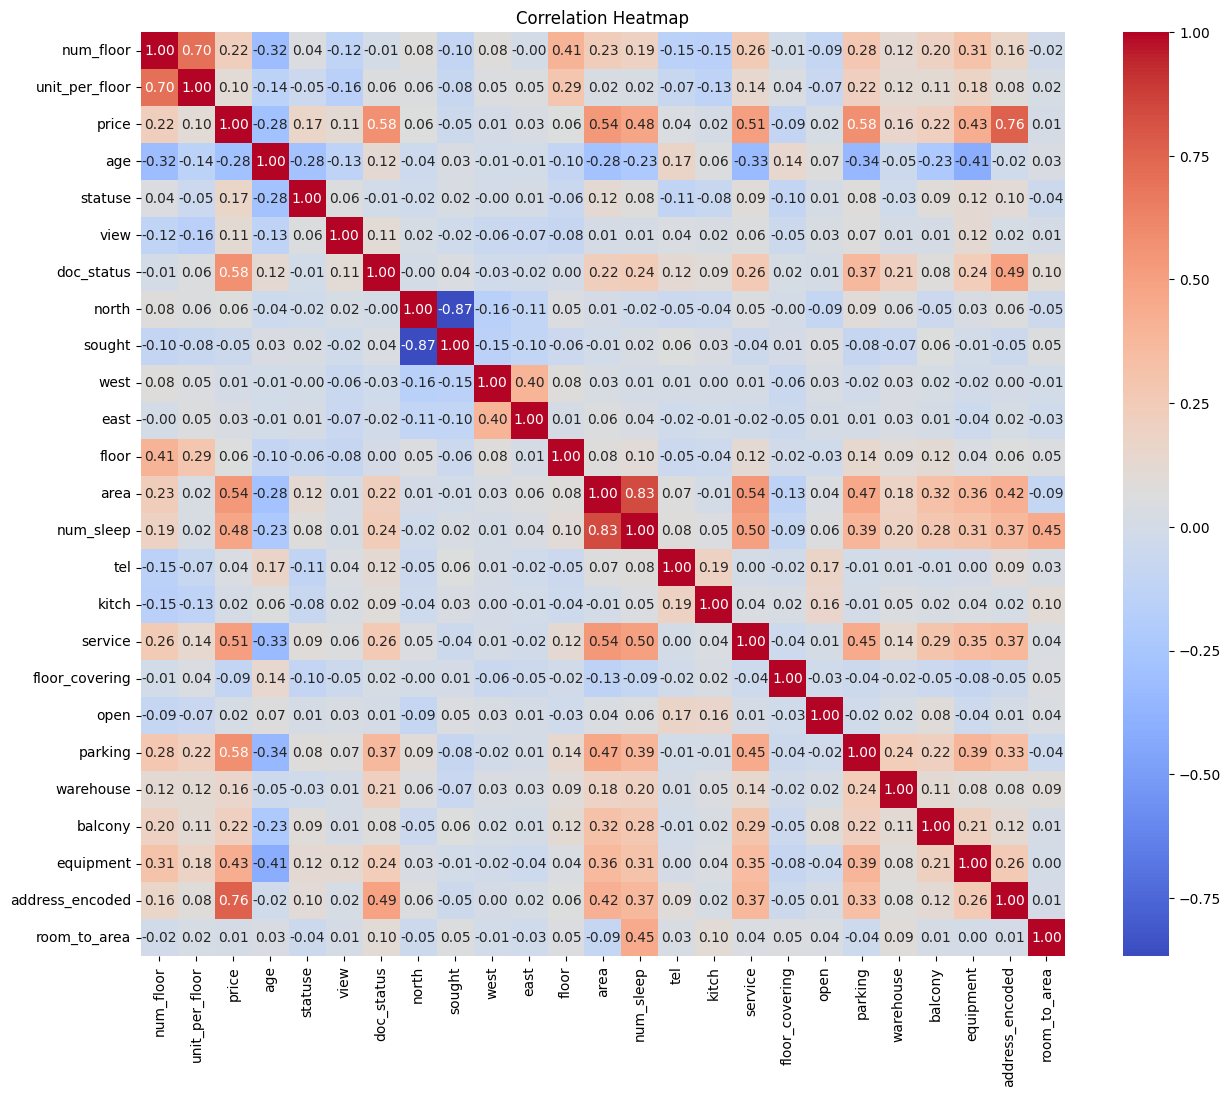

In [19]:
corr_matrix = df.corr()
plt.figure(figsize = (15, 12))
sns.heatmap(corr_matrix, annot=True, fmt = ".2f", cmap = 'coolwarm', square = True, cbar = True)
plt.title("Correlation Heatmap")
plt.show()

In [20]:
corr_matrix

,num_floor,unit_per_floor,price,age,statuse,view,doc_status,north,sought,west,...,kitch,service,floor_covering,open,parking,warehouse,balcony,equipment,address_encoded,room_to_area
num_floor,1.000000,0.704251,0.221412,-0.317040,0.044851,-0.119842,-0.006151,0.075712,-0.095895,0.076871,...,-0.154861,0.255521,-0.007336,-0.092137,0.278816,0.118784,0.196104,0.310176,0.164527,-0.015035
unit_per_floor,0.704251,1.000000,0.103387,-0.137882,-0.052824,-0.157368,0.056530,0.058167,-0.075646,0.049663,...,-0.125090,0.138888,0.042659,-0.070682,0.217553,0.115322,0.110734,0.181424,0.084082,0.017807
price,0.221412,0.103387,1.000000,-0.284716,0.167079,0.114185,0.576734,0.060684,-0.046662,0.007550,...,0.015213,0.508912,-0.094382,0.017039,0.579264,0.160948,0.218099,0.434286,0.759660,0.011020
age,-0.317040,-0.137882,-0.284716,1.000000,-0.280969,-0.130199,0.121677,-0.041263,0.030255,-0.013344,...,0.058248,-0.329514,0.141054,0.070443,-0.343699,-0.049092,-0.230011,-0.408928,-0.022864,0.033385
statuse,0.044851,-0.052824,0.167079,-0.280969,1.000000,0.056669,-0.011667,-0.021652,0.024080,-0.003585,...,-0.077370,0.087763,-0.100464,0.013125,0.076591,-0.026762,0.085495,0.119633,0.102247,-0.042984
view,-0.119842,-0.157368,0.114185,-0.130199,0.056669,1.000000,0.107350,0.020961,-0.022051,-0.058082,...,0.024874,0.058940,-0.045916,0.028855,0.068325,0.013360,0.013188,0.122788,0.017936,0.008524
doc_status,-0.006151,0.056530,0.576734,0.121677,-0.011667,0.107350,1.000000,-0.003194,0.039099,-0.025764,...,0.085435,0.260565,0.016090,0.010489,0.368746,0.214058,0.076419,0.239681,0.491340,0.103686
north,0.075712,0.058167,0.060684,-0.041263,-0.021652,0.020961,-0.003194,1.000000,-0.866980,-0.160139,...,-0.038536,0.048426,-0.000410,-0.091695,0.088834,0.056161,-0.050186,0.032287,0.058984,-0.045981
sought,-0.095895,-0.075646,-0.046662,0.030255,0.024080,-0.022051,0.039099,-0.866980,1.000000,-0.148776,...,0.034778,-0.044574,0.005683,0.051658,-0.082860,-0.068350,0.064796,-0.007046,-0.050104,0.053551
west,0.076871,0.049663,0.007550,-0.013344,-0.003585,-0.058082,-0.025764,-0.160139,-0.148776,1.000000,...,0.003236,0.010336,-0.062597,0.028516,-0.015878,0.031285,0.018312,-0.019842,0.003512,-0.012309


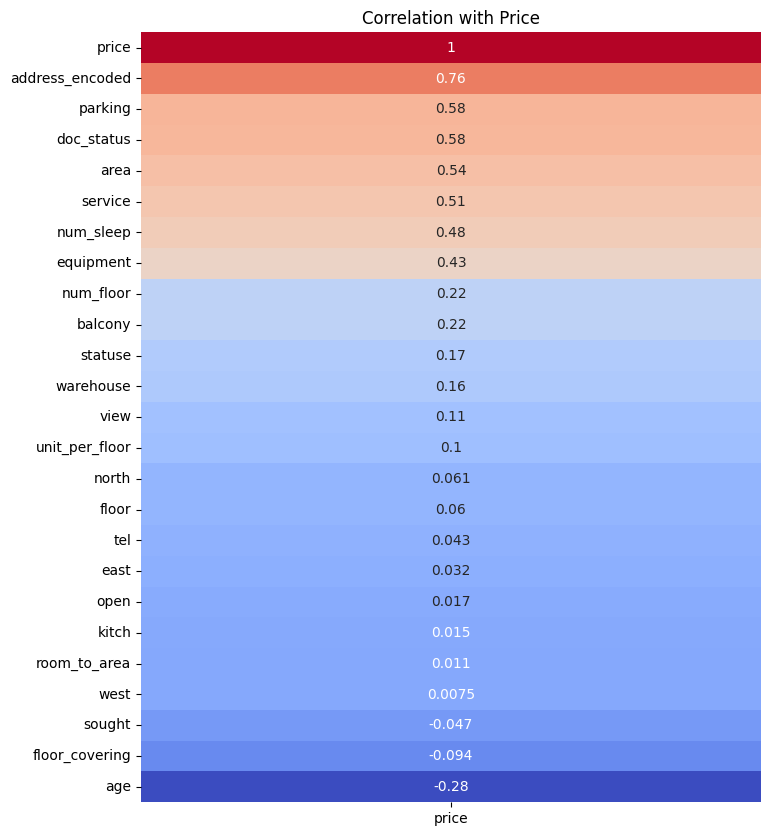

In [21]:
price_corr = df.corr()['price'].sort_values(ascending = False)
plt.figure(figsize = (8, 10))
sns.heatmap(price_corr.to_frame(), annot = True, cmap = 'coolwarm', cbar = False)
plt.title("Correlation with Price")
plt.show()

### Scatter of all features vs price

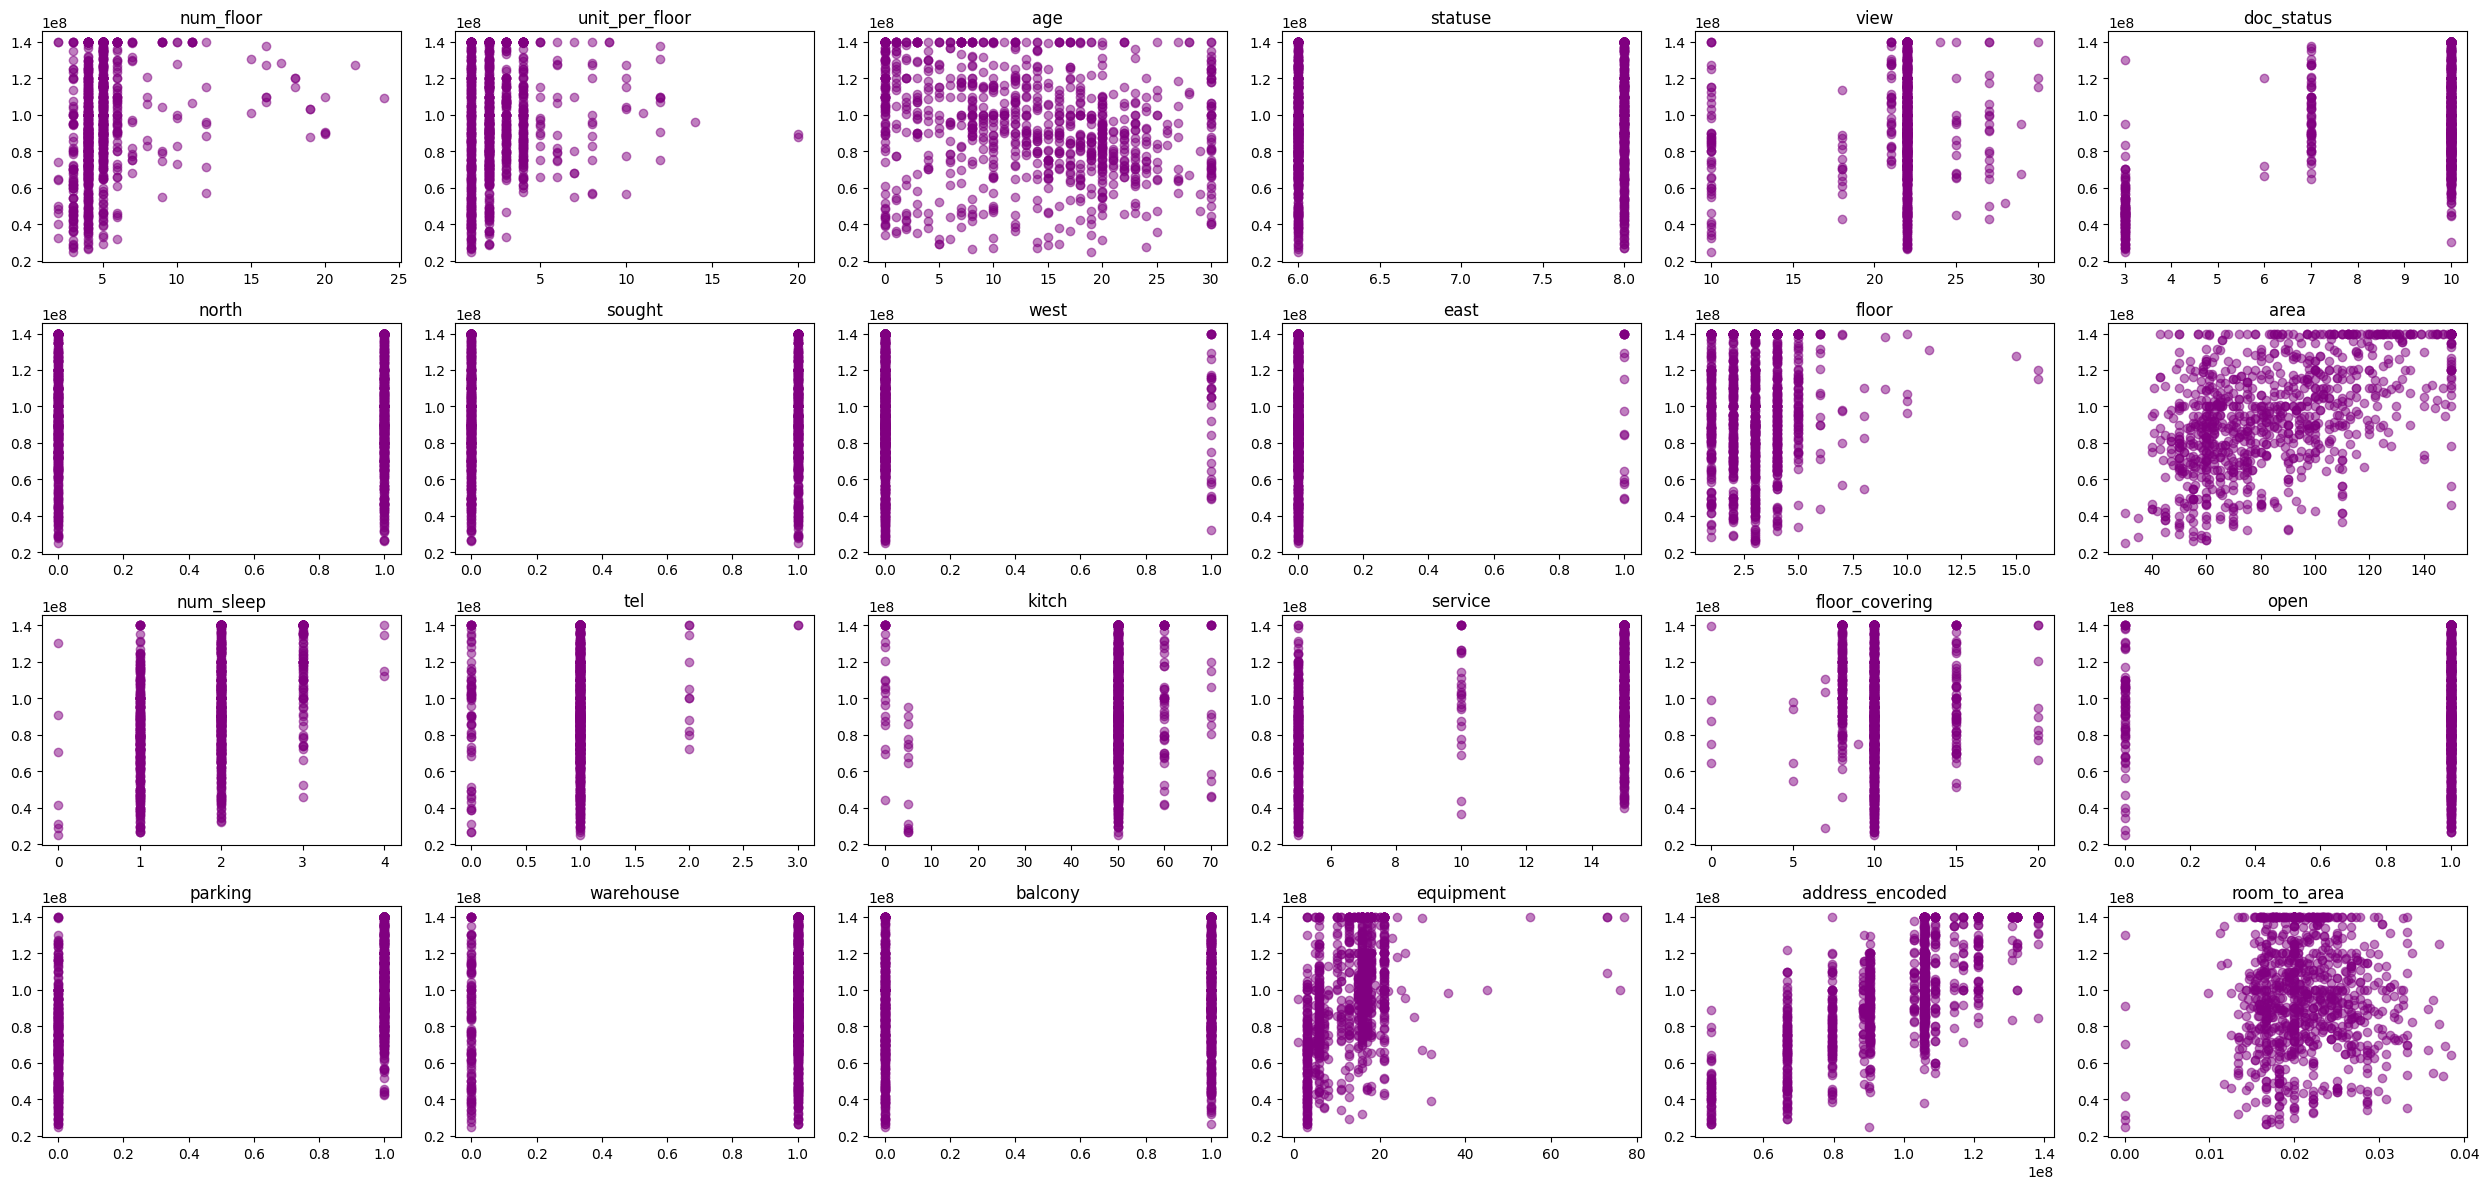

In [22]:
fig, axes = plt.subplots(4, 6, figsize=(25,12))
for i, col in enumerate(df.drop("price" , axis = 1)):
    ax = axes[i//6, i%6]
    ax.scatter(df[col], df.price, alpha=0.5 , c = "purple")
    ax.set_title(col)
plt.tight_layout()
plt.show()

### -Illustrating Scatter plot of (Area vs Price)

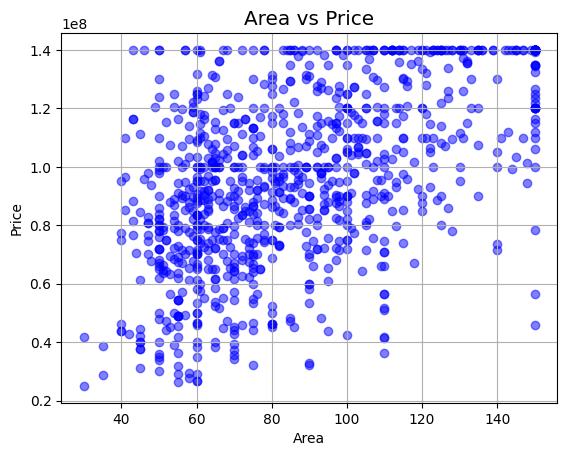

In [23]:
plt.Figure(figsize = (12, 12))
plt.scatter(df['area'], df['price'], alpha=.5, c = 'b')
plt.style.use('ggplot')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.grid(True)
plt.show()

### Number of Houses in Diff Area

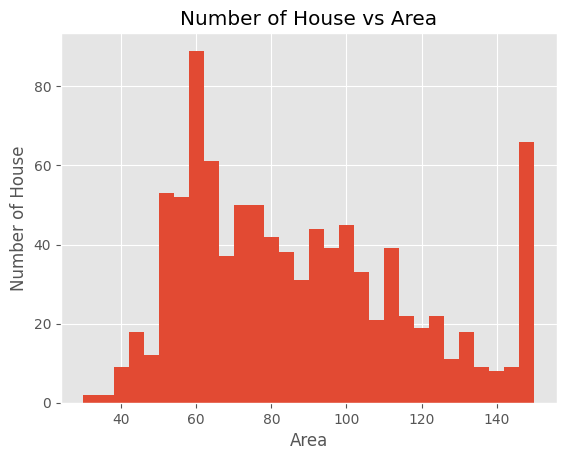

In [24]:
plt.hist(df['area'], bins=30)
plt.xlabel('Area')
plt.ylabel('Number of House')
plt.title('Number of House vs Area')
plt.show()

## Preprocessing & Feature Engineering Section

### - Checking: Is there any house over maximum price?

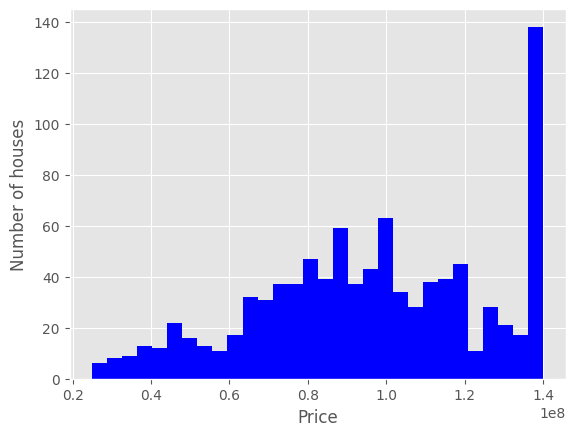

In [25]:
plt.hist(df['price'], bins=30, color='Blue')
plt.xlabel('Price')
plt.ylabel('Number of houses')
plt.show()

In [75]:
# We really have it so we have to correct it!
# Continue in future!

In [76]:
# df = df[df['price'] < 140000000.0]
# such a fool idea

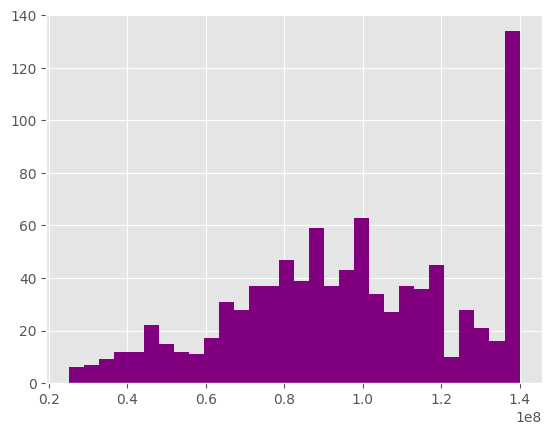

In [77]:
plt.hist(df['price'], bins=30, color='Purple')
plt.show()

### Drop duplicated and Nan data

In [78]:
df = df.dropna()
df.drop_duplicates(inplace = True)

### Feature-Target Separation
- Separate features (X) and target variable (y).

In [79]:
len(df)

932

In [80]:
features = ['num_floor', 'unit_per_floor', 'age', 'statuse', 'view',
       'doc_status', 'floor', 'area',
       'num_sleep', 'tel', 'service', 'floor_covering', 'open',
       'parking', 'warehouse', 'balcony', 'equipment', 'address_encoded']

len(features)


18

In [81]:
X = df[features]
Y = df['price']
X.shape, Y.shape

((932, 18), (932,))

### Train-Test-Split

In [82]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = .2, random_state = 42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((745, 18), (187, 18), (745,), (187,))

### Validation-Test-Split

In [83]:
x_validation, x_test, y_validation, y_test = train_test_split(x_test, y_test, random_state = 42, test_size = .5)
x_validation.shape, x_test.shape

((93, 18), (94, 18))

###  Scaler -> Standard Scaler

In [84]:
x_scaler = StandardScaler()

x_train_scaled = x_scaler.fit_transform(x_train)
x_validation_scaled  = x_scaler.transform(x_validation)
x_test_scaled = x_scaler.transform(x_test)

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(np.array(y_train).reshape(-1, 1))
y_validation_scaled  = y_scaler.transform(np.array(y_validation).reshape(-1, 1))
y_test_scaled  = y_scaler.transform(np.array(y_test).reshape(-1, 1))

## Deep Learning Regression Model

### Setting Device

In [85]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [86]:
torch.cuda.get_device_name()

'NVIDIA GeForce RTX 5060 Laptop GPU'

## Neural Network Architecture

In [191]:
class ManualReggression(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(in_features = 18, out_features = 14, bias= True)
        self.fc2 = nn.Linear(in_features = 14, out_features = 8, bias=True)
        self.fc3 = nn.Linear(in_features = 8, out_features = 1, bias=True)
        self.dropout = nn.Dropout(.005)
        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.dropout(self.relu(self.fc1(x)))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)

        return x


In [197]:
torch.manual_seed(42)
model = ManualReggression().to(device)

### Converting Data to Tensor

In [198]:
x_train_scaled_tensor=torch.tensor(x_train_scaled,dtype=torch.float32, device=device)
x_validation_scaled_tensor = torch.tensor(x_validation_scaled, dtype=torch.float32, device=device)
x_test_scaled_tensor = torch.tensor(x_test_scaled, dtype=torch.float32, device=device)
y_train_scaled_tensor = torch.tensor(y_train_scaled, dtype=torch.float32, device=device)
y_validation_scaled_tensor = torch.tensor(y_validation_scaled, dtype=torch.float32, device=device)
y_test_scaled_tensor = torch.tensor(y_test_scaled, dtype=torch.float32, device=device)

## Training Model -> Adam Optimizer

In [199]:
train_losses = []
test_losses = []
val_losses = []
loss_function = nn.MSELoss()
epochs = 0

C:\Users\Asus\AppData\Local\Temp\ipykernel_21552\3071276313.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_loss = loss_function(torch.tensor(y_pred_val).to(device), torch.tensor(y_validation_scaled).to(device))


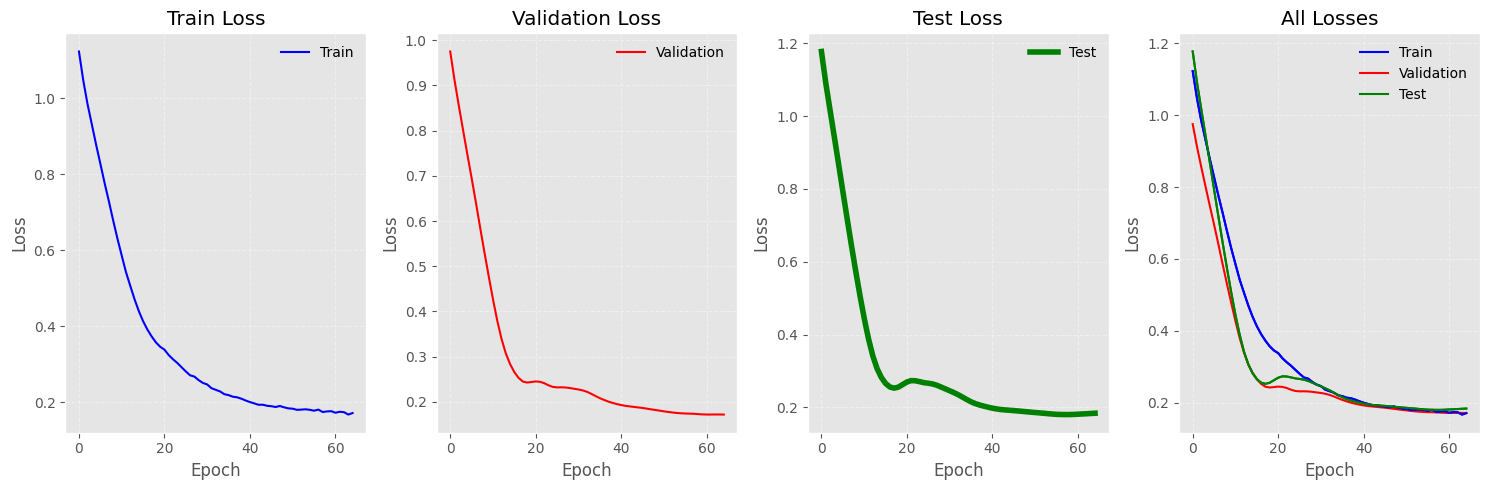

In [200]:
epoch = 65
loss_function = nn.MSELoss()
lr = .01
optimizer = optim.Adam(model.parameters(), lr = lr)
epochs = epochs + epoch
for i in range(epoch):
    model.train()
    y_pred_train = model(x_train_scaled_tensor)
    loss = loss_function(y_train_scaled_tensor, y_pred_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_losses.append(loss.detach().cpu().item())

    model.eval()
    with torch.no_grad():
        y_pred_val = model(x_validation_scaled_tensor)
        val_loss = loss_function(torch.tensor(y_pred_val).to(device), torch.tensor(y_validation_scaled).to(device))
        val_losses.append(val_loss.cpu().detach().numpy())
        y_pred_test = model(x_test_scaled_tensor)
        test_loss = loss_function(y_test_scaled_tensor, y_pred_test)
        test_losses.append(test_loss.cpu().detach().numpy())
    if (i+1) % 100 == 0:
        print(f"{i+1} : {loss.item()} , validation: {val_loss.item()} , test : {test_loss.item()}") 
    
fig, axes = plt.subplots(1, 4, figsize=(15,5))
axes[0].plot(range(epochs), train_losses, c="blue" , label = "Train" )
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(loc = "upper right" , frameon = False)
axes[0].grid(True , linestyle = "--" , alpha = .4)

axes[1].plot(range(epochs), val_losses, c="red" , label = "Validation" )
axes[1].set_title("Validation Loss")
axes[1].legend(loc = "upper right" , frameon = False)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True , linestyle = "--" , alpha = .4)

axes[2].plot(range(epochs), test_losses, c="green" , label = "Test"  , linewidth = 4)
axes[2].set_title("Test Loss")
axes[2].legend(loc = "upper right" , frameon = False)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].grid(True , linestyle = "--" , alpha = .4)

axes[3].plot(range(epochs) , train_losses , c = "blue" , label = "Train" )
axes[3].plot(range(epochs) , val_losses , c = "red" , label = "Validation" )
axes[3].plot(range(epochs) , test_losses , c = "green" , label = "Test" )
axes[3].legend(frameon = False , loc = "upper right")
axes[3].set_title("All Losses")
axes[3].set_xlabel("Epoch")
axes[3].set_ylabel("Loss")
axes[3].grid(True , linestyle = "--" , alpha = .4)
plt.plot(range(epochs) , train_losses, c = 'blue', label = 'train')
plt.plot(range(epochs) , test_losses, c = 'green', label = 'val')

plt.tight_layout()
plt.show()


## R2_SCORES

In [201]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred_test = y_pred_test.detach().cpu().numpy()
y_test_scaled_tensor = y_test_scaled_tensor.detach().cpu().numpy()
MAE = mean_absolute_error(y_pred_test, y_test_scaled_tensor)
MSE = mean_squared_error(y_pred_test, y_test_scaled_tensor)
RMSE = MSE ** .5
r2_test = r2_score(y_pred_test, y_test_scaled_tensor)
r2_val = r2_score(y_pred_val.detach().cpu().numpy(), y_validation_scaled_tensor.detach().cpu().numpy())
MAE, MSE, RMSE, r2_test, r2_val, 

(0.34015464782714844,
 0.18400591611862183,
 0.4289591077464399,
 0.8106760382652283,
 0.8042256236076355)

In [202]:
train_losses[-1], val_losses[-1], test_losses[-1]

(0.17132192850112915, array(0.17171761), array(0.18400593, dtype=float32))